In [ ]:
# Primero hay que instalar el ambiente.
# Recomiendo micromamba porque conda se demora mucho
# micromamba create -n CNN_OGLE_legacy -f 2dhistogramCNN.yml

In [1]:
from CNN_2dhist_function import *

2026-02-19 11:53:32,265	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
model_softmax = make_model()
#Tenemos distintos pesos con diferentes formas de entrenar
model_softmax.load_weights("Weights/batchBalanced_Number_M/cp.ckpt")

2026-02-19 11:53:34.182327: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Using 2d Histograms

Como ejemplo descarguemos una estrella aleatorea de OGLE. En descarga wget hay que poner 2 paths ya que podemos tener el mismo ogle ID en OGLE III y OGLE IV

In [54]:
catalog = pd.read_csv("prueba_8mil.csv")
database, ogle_id,period = catalog.sample(1,random_state=40)[["database", "ID","per"]].iloc[0]
descarga_wget(database,ogle_id,".",".")

100% [................................................................................] 6552 / 6552

1

Text(0, 0.5, 'mag I')

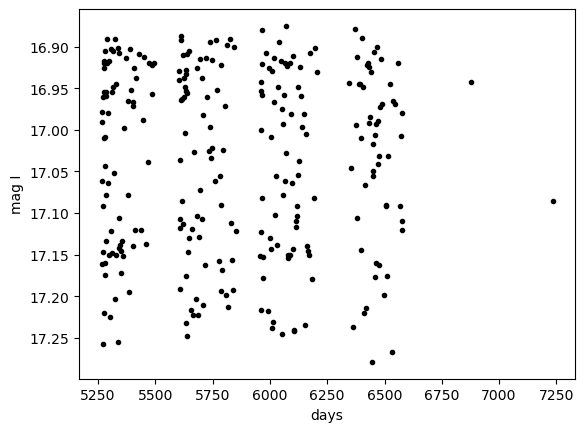

In [55]:
df = pd.read_csv(f"{ogle_id}.dat",delim_whitespace=True,names=["jd","mag","err"])
plt.plot(df.jd,df.mag,"k.")
plt.gca().invert_yaxis()
plt.xlabel("days")
plt.ylabel("mag I")

Esta parte es simplemente para hacer el mismo tratamiento de datos que se usó en el paper.
La fase se calcula simplemente con np.mod, pero hacemos un sigma clipping de 3 sigmas y, si tiene más de 2000 observaciones, lo dejamos con un máximo de 2000.
No sé cuántas observaciones tienes en tu base de datos, pero si son demasiadas habría que quitar esta parte del límite máximo de observaciones.

In [56]:
fase_clean, mag_clean, t_clean = fase_datos(per_vsx=period, df=df)

In [57]:
hdu = make_2d_histogram(32+1,32+1,mag_clean,fase_clean, norm_max="max")

In [73]:
data = hdu.data

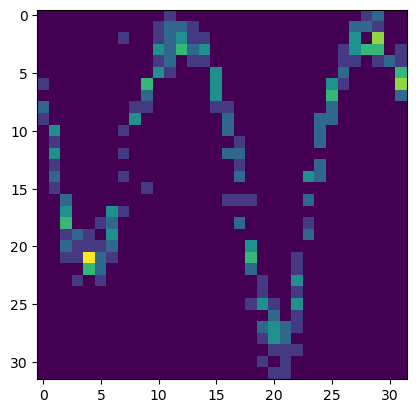

In [74]:
plt.imshow(data)

In [75]:
#Esto es simplemente por la forma de los arrays que necesita. ahora es una imagen con 1 canal
data = np.expand_dims(data,-1)
np.shape(data)

(32, 32, 1)

In [77]:
#Y tambien tenemos que expandir por el numero de ejemplos que queremos predecir 
data = np.expand_dims(data,0)
np.shape(data)
# ahora es 1 ejemplo que queremos clasificar de tamagno 32,32, de 1 canal (por ejemplo imagenes RGB tienen 3 canales)

(1, 32, 32, 1)

In [84]:
class_names = ['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR','Rndm']

In [85]:
predict_results = pd.DataFrame(model_softmax.predict(data),columns=class_names)

In [86]:
predict_results

,ELL,M,CEP,DST,E,LPV,RR,Rndm
0,0.065667,0.000026,0.000013,3.975640e-07,0.933591,0.000054,1.497797e-07,0.000648


In [87]:
#tenemos que la clasificacion de imagen nos entrega un 0.93% de ser eclipsante

In [ ]:
import gdown

file_id = "1l_JSQ_VGArZ0oTKE1k48znzz87tGYeUR"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "balanced_random_forest_model.joblib", quiet=False)

In [95]:
model = joblib.load("balanced_random_forest_model.joblib")
model.feature_names_in_


array(['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR', 'Rndm', 'per',
       'amplitud'], dtype=object)

In [94]:
#Si queremos combinarlo con el BRF hay que agregar el periodo y la amplitud

In [101]:
predict_results["amplitud"] = mag_clean.max() -mag_clean.min()
predict_results["per"] = period

In [115]:
prediction = model.predict(predict_results)
prediction_prob = model.predict_proba(predict_results)

/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)
/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)


In [116]:
pred_class = prediction[0]          # escalar
prob = prediction_prob[0, pred_class]

print(
    f"The classification is {class_names[pred_class]} "
    f"with a probability of {prob:.4f}"
)


The classification is E with a probability of 1.0000


In [117]:
### Bonus si queremos usar muchas curvas de luz. En este caso voy a usar la misma para no descargar tantas ...

In [121]:
# generamos un cubo vacio
cubo_data = np.zeros((100,32,32,1))

In [128]:
#esto debiese ser los periodos asociados a cada curva de luz
random_period = np.round(np.random.uniform(0, 100, 100), 7)

In [132]:
for i in range(100):
    period = random_period[i]
    fase_clean, mag_clean, t_clean = fase_datos(per_vsx=period, df=df)
    hdu = make_2d_histogram(32+1,32+1,mag_clean,fase_clean, norm_max="max")
    data = np.expand_dims(hdu.data,-1)
    cubo_data[i] = data

In [ ]:
# asi se ven las imagenes cada una correspondiente a un periodo. 

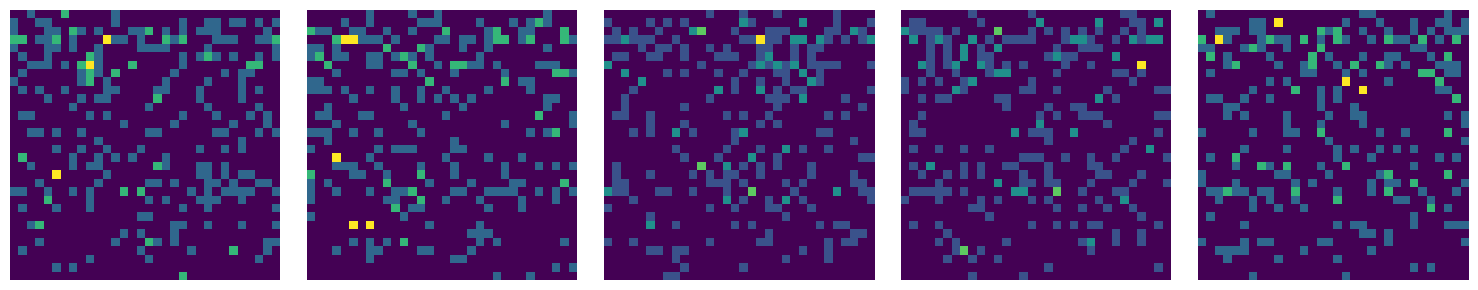

In [136]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(cubo_data[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#predecimos el cubo

In [137]:
predict_results = pd.DataFrame(model_softmax.predict(cubo_data),columns=class_names)

In [138]:
predict_results

,ELL,M,CEP,DST,E,LPV,RR,Rndm
0,1.698615e-07,0.000002,0.000021,2.531719e-10,0.000003,0.000420,0.000001,0.999552
1,6.219953e-07,0.000020,0.000006,5.084286e-09,0.000009,0.002056,0.000001,0.997907
2,6.239882e-07,0.000022,0.000027,2.009936e-09,0.000002,0.001467,0.000005,0.998476
3,1.867894e-06,0.000019,0.000105,2.516563e-09,0.000024,0.004452,0.000007,0.995393
4,2.867297e-07,0.000005,0.000132,3.200445e-10,0.000001,0.000538,0.000003,0.999321
...,...,...,...,...,...,...,...,...
95,1.080142e-06,0.000024,0.000044,1.112191e-09,0.000012,0.002252,0.000002,0.997666
96,2.266646e-06,0.000015,0.000261,2.489940e-09,0.000020,0.000881,0.000017,0.998804
97,1.253839e-06,0.000005,0.000035,2.157243e-09,0.000008,0.001250,0.000003,0.998697
98,3.275417e-05,0.000140,0.001146,4.132799e-07,0.000051,0.002651,0.000161,0.995818


In [140]:
# agregamos informacion de periodo amplitud

In [139]:
predict_results["amplitud"] = mag_clean.max() -mag_clean.min()
predict_results["per"] = random_period

In [141]:
prediction = model.predict(predict_results)
prediction_prob = model.predict_proba(predict_results)

/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)
/home/nicolas/.local/share/mamba/envs/CNN_OGLE_legacy/lib/python3.8/site-packages/sklearn/base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names must be in the same order as they were in fit.

  warnings.warn(message, FutureWarning)


In [142]:
prediction

array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7])

In [150]:
# todas son clasificadas como 7 que corresponde a la clase random

In [149]:
predict_results_BRF = pd.DataFrame(prediction_prob,columns=class_names)
predict_results_BRF

,ELL,M,CEP,DST,E,LPV,RR,Rndm
0,0.0,0.006,0.002,0.0,0.000,0.0,0.000,0.992
1,0.0,0.002,0.000,0.0,0.002,0.0,0.022,0.974
2,0.0,0.012,0.000,0.0,0.002,0.0,0.006,0.980
3,0.0,0.014,0.000,0.0,0.004,0.0,0.026,0.956
4,0.0,0.014,0.002,0.0,0.000,0.0,0.000,0.984
...,...,...,...,...,...,...,...,...
95,0.0,0.006,0.000,0.0,0.002,0.0,0.006,0.986
96,0.0,0.016,0.002,0.0,0.002,0.0,0.008,0.972
97,0.0,0.012,0.000,0.0,0.000,0.0,0.000,0.988
98,0.0,0.026,0.008,0.0,0.012,0.0,0.000,0.954
